In [185]:
import statsmodels.api as sm
import gpboost as gpb
import numpy as np
import matplotlib.pyplot as plt
import engression
import torch
import time
import pandas as pd
import gpytorch as gpy
from engression import engression
plt.style.use('ggplot')
from lagp.utils.gpytorch_utils import GPRegressionModel, AsymmetricLaplaceLikelihood

In [186]:
# load qgam results
qgam = pd.read_csv("../results/realdata/qgam_acceleration.csv")

In [187]:
pred_qgam = qgam["fit"]
print(pred_qgam.shape)

(1000,)


In [188]:
X_pred = qgam["times"]

In [189]:
# Load the dataset
mcycle = sm.datasets.get_rdataset("mcycle", "MASS")
df = mcycle.data
N = len(df)
# Check it out
print(df.shape)

(133, 2)


In [190]:
X = df["times"]
y = df["accel"]

In [191]:
delta_logl = 1
q = 0.8
likelihood = "asymmetric_laplace_constant_curvature_fisher_mode_finding" #
gpq = gpb.GPModel(gp_coords  = X ,
                    cov_function="matern",
                    cov_fct_shape= 1.5,
                    likelihood=likelihood, 
                    likelihood_additional_param = q, 
                    cover_tree_radius = delta_logl)
params = {"estimate_aux_pars": True, "init_aux_pars" : np.array([1]), "trace":False}
gpq.fit(X = np.ones(N), y=y, params = params) 

[GPBoost] [Info] Using CC_LLS_MIN_DECREASE_LOG_LIKE_ = 1
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 25, delta_mode_ = 13.0565, delta_log_like_up_ = 38.4087, delta_log_like_down_ = 421.689
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 25, delta_mode_ = 16.6419, delta_log_like_up_ = 20.5213, delta_log_like_down_ = 211.371
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 25, delta_mode_ = 11.8187, delta_log_like_up_ = 1.00049, delta_log_like_down_ = 82.7621
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 25, delta_mode_ = 12.4024, delta_log_like_up_ = 1.00014, delta_log_like_down_ = 53.1211
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 26, delta_mode_ = 12.8221, delta_log_like_up_ = 1.00039, delta_log_like_down_ = 41.212
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 26, delta_mode_ = 13.0375, delta_log_like_up_ = 1.00021, delta_log_like_down_ = 36.5434
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 26, delta_

In [192]:
pred_gpb = gpq.predict(X_pred = np.ones(len(X_pred)), 
                   gp_coords_pred = X_pred, predict_response=False, 
                   predict_var=True) # get the latent

[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 21, delta_mode_ = 2.84089, delta_log_like_up_ = 6.59462, delta_log_like_down_ = 7.54709


In [198]:
gpq.get_coef()

,Covariate_1
Param.,6.188419


In [193]:
gpq.get_aux_pars()

,scale
Param.,4.158118


In [194]:
gpq.get_cov_pars()

,GP_var,GP_range
Param.,786.540347,10.048639


In [202]:
# Assuming train_X, train_y, test_X, test_y are numpy arrays
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)
X_pred_tensor = torch.tensor(X_pred, dtype=torch.float32)

likelihood = AsymmetricLaplaceLikelihood(quantile=q)
model = GPRegressionModel(X_tensor, 1000, 500)  # Instantiate the GPyTorch model

# ---- Training ----
model.train()
likelihood.train()

optimizer = torch.optim.Adam(
                        [
                        {"params": model.parameters()},
                        {"params": likelihood.parameters()},
                        ],
                        lr=0.1,
                        )

mll = gpy.mlls.VariationalELBO(likelihood, model, num_data=y_tensor.size(0))

num_epochs = 500
start_time = time.time()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = -mll(output, y_tensor)
    loss.backward()
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")
    optimizer.step()
    end_time = time.time()
    elapsed_time = end_time - start_time

# ---- Evaluation ----
model.eval()
likelihood.eval()
with torch.no_grad():
    pred = model(X_pred_tensor)

Epoch 0: Loss = 13.5036
Epoch 50: Loss = 6.0850
Epoch 100: Loss = 5.6915
Epoch 150: Loss = 5.5167
Epoch 200: Loss = 5.4113
Epoch 250: Loss = 5.3486
Epoch 300: Loss = 5.3006
Epoch 350: Loss = 5.2583
Epoch 400: Loss = 5.2394
Epoch 450: Loss = 5.2268


In [196]:
pred_gpy = pred.mean

Text(0.5, 1.0, 'Quantile: 0.8')

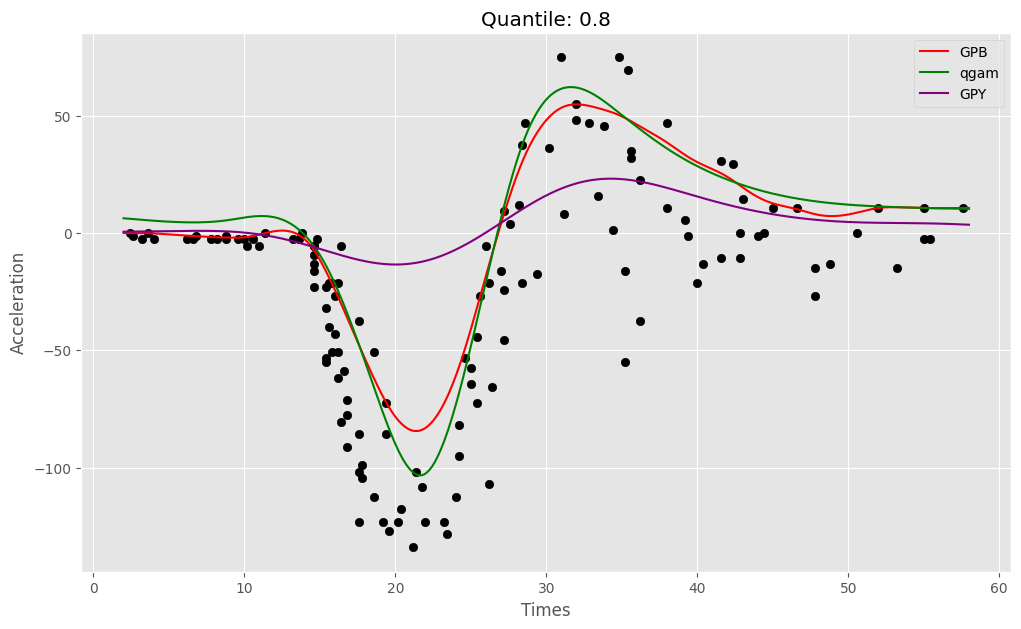

In [199]:
y_pred =  pred_gpb["mu"]
var_pred = pred_gpb["var"]
lower = y_pred - 2*np.sqrt(var_pred)
upper = y_pred + 2*np.sqrt(var_pred)
plt.figure(figsize=(12,7))
plt.plot(X_pred, y_pred, color = "red", label = "GPB")
plt.plot(X_pred, pred_qgam, color = "green", label = "qgam")
plt.plot(X_pred, pred_gpy, color = "purple", label = "GPY")
# plt.fill_between(X_pred, y1 = lower, y2 = upper, color = "lightgreen", alpha = 0.5)
plt.scatter(X, y, color = "black")
plt.xlabel("Times")
plt.ylabel("Acceleration")
plt.legend(labelcolor = "black")
plt.title(f"Quantile: {q}", color = "black")